In [1]:
import os
import copy
import random
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnF
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.transforms.v2 as transforms

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 16
    epochs: int = 10
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    train_split: float = 0.8
    num_workers: int = 2 if os.name != "nt" else 0
    pin_memory: bool = torch.cuda.is_available()
    seed: int = 42
    threshold: float = 0.5
    encoder_channels: tuple = (32, 64, 128, 256)
    use_batchnorm: bool = False
    dropout: float = 0.0

    def clone(self, **kwargs):
        cfg = Config(**asdict(self))
        for key, value in kwargs.items():
            setattr(cfg, key, value)
        return cfg

seed_everything()
config = Config()

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=False, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm)
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        layers.append(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm)
        )
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        encoder_channels=(32, 64, 128, 256),
        use_batchnorm=False,
        dropout=0.0,
    ):
        super().__init__()

        self.encoder_blocks = nn.ModuleList()
        prev_channels = in_channels
        for channels in encoder_channels:
            self.encoder_blocks.append(
                ConvBlock(prev_channels, channels, use_batchnorm=use_batchnorm, dropout=dropout)
            )
            prev_channels = channels

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        bottleneck_channels = encoder_channels[-1] * 2
        self.bottleneck = ConvBlock(
            encoder_channels[-1],
            bottleneck_channels,
            use_batchnorm=use_batchnorm,
            dropout=dropout,
        )

        self.upconvs = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        decoder_in_channels = bottleneck_channels

        for channels in reversed(encoder_channels):
            self.upconvs.append(
                nn.ConvTranspose2d(decoder_in_channels, channels, kernel_size=2, stride=2)
            )
            self.decoder_blocks.append(
                ConvBlock(channels * 2, channels, use_batchnorm=use_batchnorm, dropout=dropout)
            )
            decoder_in_channels = channels

        self.head = nn.Conv2d(encoder_channels[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for block in self.encoder_blocks:
            x = block(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for upconv, block, skip in zip(self.upconvs, self.decoder_blocks, reversed(skip_connections)):
            x = upconv(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = nnF.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = block(x)

        return self.head(x)

In [4]:
class PetDataset(Dataset):
    def __init__(self, root, image_size=(128, 128), split="trainval", augment=False):
        self.root = root
        self.image_size = image_size
        self.augment = augment
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask != 2).astype(np.uint8)
        mask = Image.fromarray(mask)

        image = TF.resize(image, self.image_size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.image_size, interpolation=InterpolationMode.NEAREST)

        if self.augment and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        mask = TF.pil_to_tensor(mask).float()

        return image, mask

In [5]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce = nnF.binary_cross_entropy_with_logits(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        denominator = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = 1 - ((2 * intersection + self.smooth) / (denominator + self.smooth)).mean()
        return bce + dice

def segmentation_metrics(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    iou = ((intersection + eps) / (union + eps)).mean().item()
    f1 = (
        (2 * intersection + eps)
        / (preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + eps)
    ).mean().item()

    return iou, f1

class Trainer:
    def __init__(self, config):
        seed_everything(config.seed)
        self.config = config

        self.model = UNet(
            in_channels=3,
            out_channels=1,
            encoder_channels=config.encoder_channels,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout,
        ).to(config.device)

        self.criterion = DiceBCELoss()
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_iou": [],
            "val_iou": [],
            "train_f1": [],
            "val_f1": [],
        }
        self.best_state = None
        self.best_val_iou = -1.0

        self.setup_dataloader()

    def setup_dataloader(self):
        trainval_train = PetDataset(
            root="./data",
            image_size=self.config.image_size,
            split="trainval",
            augment=True,
        )
        trainval_eval = PetDataset(
            root="./data",
            image_size=self.config.image_size,
            split="trainval",
            augment=False,
        )

        dataset_size = len(trainval_train)
        train_size = int(self.config.train_split * dataset_size)
        generator = torch.Generator().manual_seed(self.config.seed)
        indices = torch.randperm(dataset_size, generator=generator).tolist()
        train_indices = indices[:train_size]
        val_indices = indices[train_size:]

        self.train_dataset = Subset(trainval_train, train_indices)
        self.val_dataset = Subset(trainval_eval, val_indices)
        self.test_dataset = PetDataset(
            root="./data",
            image_size=self.config.image_size,
            split="test",
            augment=False,
        )

        loader_kwargs = {
            "num_workers": self.config.num_workers,
            "pin_memory": self.config.pin_memory,
        }

        self.train_dataloader = DataLoader(
            self.train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            **loader_kwargs,
        )
        self.val_dataloader = DataLoader(
            self.val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            **loader_kwargs,
        )
        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            **loader_kwargs,
        )

    def train_epoch(self):
        self.model.train()
        epoch_loss = 0.0
        epoch_iou = 0.0
        epoch_f1 = 0.0

        for images, masks in tqdm(self.train_dataloader, leave=False):
            images = images.to(self.config.device, non_blocking=True)
            masks = masks.to(self.config.device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            iou, f1 = segmentation_metrics(outputs.detach(), masks, self.config.threshold)

            epoch_loss += loss.item()
            epoch_iou += iou
            epoch_f1 += f1

        n_batches = len(self.train_dataloader)
        return epoch_loss / n_batches, epoch_iou / n_batches, epoch_f1 / n_batches

    def evaluate(self, dataloader):
        self.model.eval()
        epoch_loss = 0.0
        epoch_iou = 0.0
        epoch_f1 = 0.0

        with torch.no_grad():
            for images, masks in tqdm(dataloader, leave=False):
                images = images.to(self.config.device, non_blocking=True)
                masks = masks.to(self.config.device, non_blocking=True)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                iou, f1 = segmentation_metrics(outputs, masks, self.config.threshold)

                epoch_loss += loss.item()
                epoch_iou += iou
                epoch_f1 += f1

        n_batches = len(dataloader)
        return epoch_loss / n_batches, epoch_iou / n_batches, epoch_f1 / n_batches

    def validate(self):
        return self.evaluate(self.val_dataloader)

    def test(self):
        return self.evaluate(self.test_dataloader)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss, train_iou, train_f1 = self.train_epoch()
            val_loss, val_iou, val_f1 = self.validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["train_iou"].append(train_iou)
            self.history["val_iou"].append(val_iou)
            self.history["train_f1"].append(train_f1)
            self.history["val_f1"].append(val_f1)

            if val_iou > self.best_val_iou:
                self.best_val_iou = val_iou
                self.best_state = copy.deepcopy(self.model.state_dict())

            print(
                f"Epoch {epoch + 1}/{self.config.epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train IoU: {train_iou:.4f} | "
                f"Val IoU: {val_iou:.4f} | "
                f"Train F1: {train_f1:.4f} | "
                f"Val F1: {val_f1:.4f}"
            )

        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)

        test_loss, test_iou, test_f1 = self.test()

        print(
            f"Test Loss: {test_loss:.4f} | "
            f"Test IoU: {test_iou:.4f} | "
            f"Test F1: {test_f1:.4f}"
        )

        return {
            "test_loss": test_loss,
            "test_iou": test_iou,
            "test_f1": test_f1,
            "best_val_iou": self.best_val_iou,
            "config": asdict(self.config),
        }

    def plot_history(self, title):
        epochs = np.arange(1, len(self.history["train_loss"]) + 1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(epochs, self.history["train_loss"], label="train")
        axes[0].plot(epochs, self.history["val_loss"], label="val")
        axes[0].set_title(f"{title}: loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epochs, self.history["train_iou"], label="train IoU")
        axes[1].plot(epochs, self.history["val_iou"], label="val IoU")
        axes[1].plot(epochs, self.history["train_f1"], label="train F1", linestyle="--")
        axes[1].plot(epochs, self.history["val_f1"], label="val F1", linestyle="--")
        axes[1].set_title(f"{title}: quality")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Score")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()
        fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
        axes = np.array(axes).reshape(n_samples, 3)

        with torch.no_grad():
            for i in range(n_samples):
                image, mask = self.test_dataset[i]
                logits = self.model(image.unsqueeze(0).to(self.config.device))
                pred = (torch.sigmoid(logits).squeeze(0).squeeze(0).cpu() >= self.config.threshold).float().numpy()

                image_np = image.permute(1, 2, 0).cpu().numpy()
                image_np = ((image_np * 0.5) + 0.5).clip(0, 1)

                axes[i, 0].imshow(image_np)
                axes[i, 0].set_title("Image")
                axes[i, 0].axis("off")

                axes[i, 1].imshow(mask.squeeze(0).cpu().numpy(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 1].axis("off")

                axes[i, 2].imshow(pred, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")
                axes[i, 2].axis("off")

        plt.tight_layout()
        plt.show()

In [6]:
baseline_config = config.clone(
    epochs=10,
    learning_rate=1e-3,
    batch_size=16,
    encoder_channels=(32, 64, 128, 256),
    use_batchnorm=False,
    dropout=0.0,
)

search_epochs = 6
lr_values = [1e-4, 5e-4, 1e-3]
batch_size_values = [8, 16, 32]

baseline_trainer = None
baseline_result = None
grid_results = []
best_grid_result = None
best_grid_config = None
modified_trainer = None
modified_result = None
modified_config = None

In [7]:
baseline_trainer = Trainer(baseline_config)
baseline_result = baseline_trainer.run()

for learning_rate in lr_values:
    for batch_size in batch_size_values:
        exp_config = baseline_config.clone(
            epochs=search_epochs,
            learning_rate=learning_rate,
            batch_size=batch_size,
        )
        trainer = Trainer(exp_config)
        result = trainer.run()

        grid_results.append(
            {
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "best_val_iou": result["best_val_iou"],
                "test_iou": result["test_iou"],
                "test_f1": result["test_f1"],
            }
        )

grid_results = sorted(grid_results, key=lambda x: x["best_val_iou"], reverse=True)
best_grid_result = grid_results[0]
best_grid_config = baseline_config.clone(
    epochs=10,
    learning_rate=best_grid_result["learning_rate"],
    batch_size=best_grid_result["batch_size"],
)

modified_config = best_grid_config.clone(
    use_batchnorm=True,
    dropout=0.1,
)

modified_trainer = Trainer(modified_config)
modified_result = modified_trainer.run()

print("Baseline:", baseline_result)
print("Best grid:", best_grid_result)
print("Modified:", modified_result)

100%|██████████| 792M/792M [00:34<00:00, 22.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.7MB/s]


Epoch 1/10 | Train Loss: 1.1386 | Val Loss: 0.8533 | Train IoU: 0.4464 | Val IoU: 0.5931 | Train F1: 0.5847 | Val F1: 0.7310


Epoch 2/10 | Train Loss: 0.7900 | Val Loss: 0.7329 | Train IoU: 0.6090 | Val IoU: 0.6377 | Train F1: 0.7434 | Val F1: 0.7671


Epoch 3/10 | Train Loss: 0.6907 | Val Loss: 0.7141 | Train IoU: 0.6564 | Val IoU: 0.6369 | Train F1: 0.7808 | Val F1: 0.7671


Epoch 4/10 | Train Loss: 0.6162 | Val Loss: 0.5853 | Train IoU: 0.6916 | Val IoU: 0.7033 | Train F1: 0.8067 | Val F1: 0.8162


...

Epoch 7/10 | Train Loss: 0.4285 | Val Loss: 0.3736 | Train IoU: 0.7807 | Val IoU: 0.8070 | Train F1: 0.8678 | Val F1: 0.8864


Epoch 8/10 | Train Loss: 0.4130 | Val Loss: 0.3531 | Train IoU: 0.7891 | Val IoU: 0.8145 | Train F1: 0.8734 | Val F1: 0.8913


Epoch 9/10 | Train Loss: 0.3982 | Val Loss: 0.3528 | Train IoU: 0.7953 | Val IoU: 0.8145 | Train F1: 0.8777 | Val F1: 0.8911


Epoch 10/10 | Train Loss: 0.3814 | Val Loss: 0.3610 | Train IoU: 0.8034 | Val IoU: 0.8142 | Train F1: 0.8830 | Val F1: 0.8909


Test Loss: 0.3604 | Test IoU: 0.8140 | Test F1: 0.8890
Baseline: {'test_loss': 0.43947710116272387, 'test_iou': 0.7744241971036662, 'test_f1': 0.8634676573069199, 'best_val_iou': 0.7738619511542113, 'config': {'image_size': (128, 128), 'batch_size': 16, 'epochs': 10, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'device': 'cuda', 'train_split': 0.8, 'num_workers': 2, 'pin_memory': True, 'seed': 42, 'threshold': 0.5, 'encoder_channels': (32, 64, 128, 256), 'use_batchnorm': False, 'dropout': 0.0}}
Best grid: {'learning_rate': 0.0005, 'batch_size': 8, 'best_val_iou': 0.7655827785315721, 'test_iou': 0.7743854995386793, 'test_f1': 0.8635899866068805}
Modified: {'test_loss': 0.3603917012612025, 'test_iou': 0.813960855303247, 'test_f1': 0.8889524689946559, 'best_val_iou': 0.8144907957833746, 'config': {'image_size': (128, 128), 'batch_size': 8, 'epochs': 10, 'learning_rate': 0.0005, 'weight_decay': 0.0001, 'device': 'cuda', 'train_split': 0.8, 'num_workers': 2, 'pin_memory': True, 'seed': 4

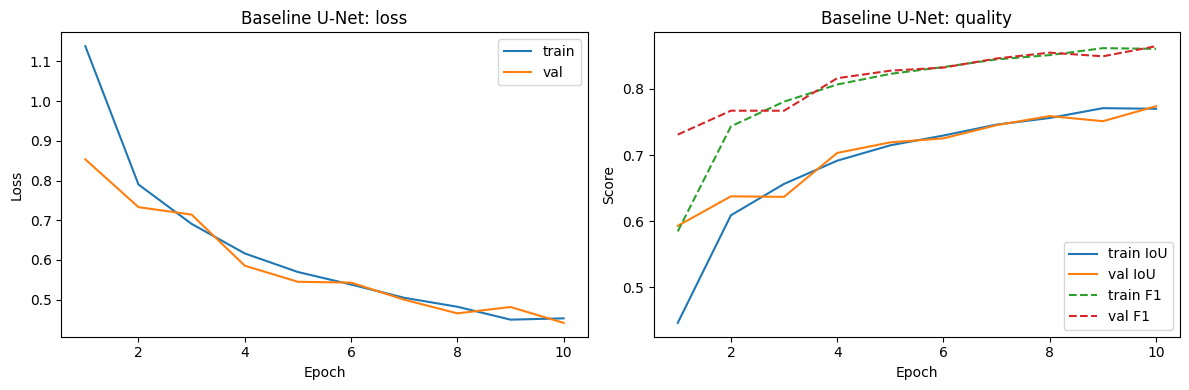

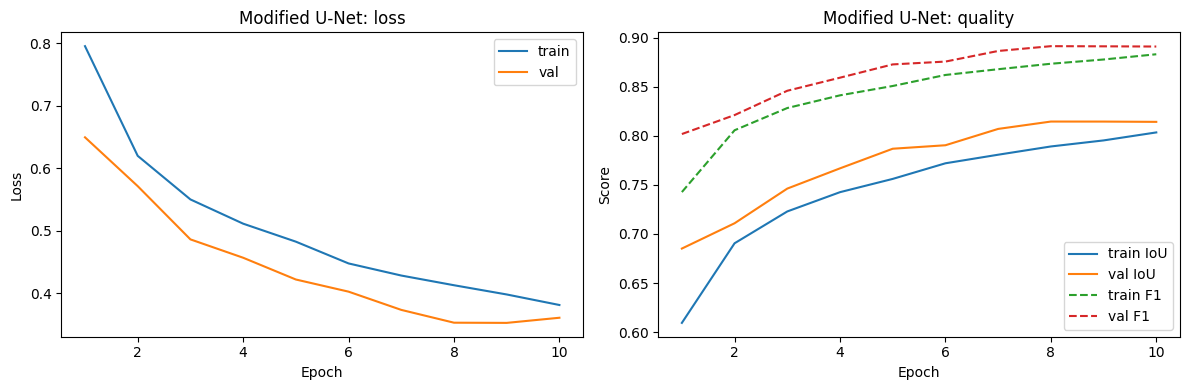

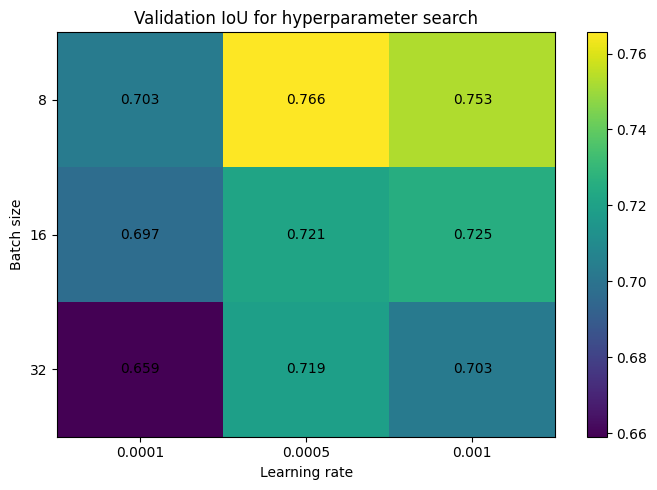

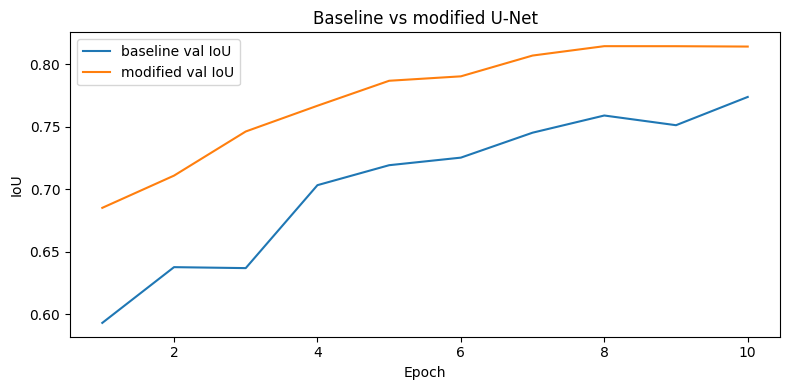

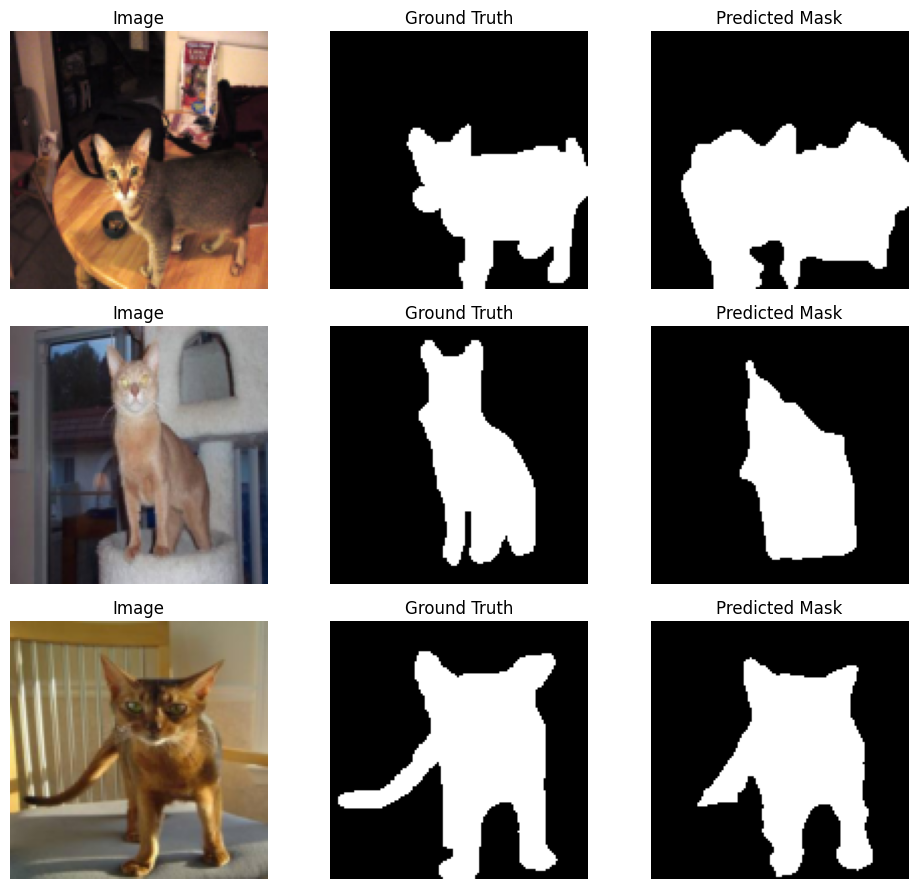

In [8]:
baseline_trainer.plot_history("Baseline U-Net")
modified_trainer.plot_history("Modified U-Net")

heatmap = np.zeros((len(batch_size_values), len(lr_values)))
for batch_idx, batch_size in enumerate(batch_size_values):
    for lr_idx, learning_rate in enumerate(lr_values):
        score = next(
            item["best_val_iou"]
            for item in grid_results
            if item["learning_rate"] == learning_rate and item["batch_size"] == batch_size
        )
        heatmap[batch_idx, lr_idx] = score

plt.figure(figsize=(7, 5))
plt.imshow(heatmap, aspect="auto")
plt.xticks(np.arange(len(lr_values)), [str(v) for v in lr_values])
plt.yticks(np.arange(len(batch_size_values)), [str(v) for v in batch_size_values])
plt.xlabel("Learning rate")
plt.ylabel("Batch size")
plt.title("Validation IoU for hyperparameter search")
for i in range(len(batch_size_values)):
    for j in range(len(lr_values)):
        plt.text(j, i, f"{heatmap[i, j]:.3f}", ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    np.arange(1, len(baseline_trainer.history["val_iou"]) + 1),
    baseline_trainer.history["val_iou"],
    label="baseline val IoU",
)
plt.plot(
    np.arange(1, len(modified_trainer.history["val_iou"]) + 1),
    modified_trainer.history["val_iou"],
    label="modified val IoU",
)
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Baseline vs modified U-Net")
plt.legend()
plt.tight_layout()
plt.show()

modified_trainer.inference_and_plot_samples(n_samples=3)

Итоги экспериментов:

1. Базовый U-Net: test IoU = 0.7744, test F1 = 0.8635
2. Лучшие гиперпараметры по валидации: learning_rate = 0.0005, batch_size = 8, best val IoU = 0.7656
3. Модифицированный U-Net: test IoU = 0.8140, test F1 = 0.8890
4. Разница modified - baseline: ΔIoU = 0.0395, ΔF1 = 0.0255

Краткие выводы
1. На сетке из 9 запусков лучший результат показала конфигурация
(learning_rate = 0.0005, batch_size = 8).

2. Learning rate = 0.0005 оказался оптимальным компромиссом между скоростью сходимости и стабильностью обучения: при меньшем значении модель недообучается, при большем — наблюдается менее стабильная динамика.

3. Меньший batch size (8) показал лучшие результаты, вероятно за счёт более шумных, но информативных градиентов, что улучшает обобщающую способность модели.

4. Модификация архитектуры (добавление BatchNorm и Dropout) привела к росту качества: test IoU увеличился с 0.7744 до 0.8140.

5. Улучшение наблюдается как на валидации, так и на тесте, что указывает на
реальное улучшение обобщающей способности, а не на случайный эффект.

6. BatchNorm стабилизирует распределение активаций и ускоряет обучение,
а Dropout выступает как регуляризация, помогая модели избегать переобучения.